In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

EDA

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
quality = pd.DataFrame({
    'dtype'       : df.dtypes,
    'null_count'  : df.isnull().sum(),
    'null_pct'    : (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique'    : df.nunique(),
    'sample_vals' : [df[c].dropna().unique()[:3].tolist() for c in df.columns]
})
print(quality)

                    dtype  null_count  null_pct  n_unique  \
customerID         object           0       0.0      7043   
gender             object           0       0.0         2   
SeniorCitizen       int64           0       0.0         2   
Partner            object           0       0.0         2   
Dependents         object           0       0.0         2   
tenure              int64           0       0.0        73   
PhoneService       object           0       0.0         2   
MultipleLines      object           0       0.0         3   
InternetService    object           0       0.0         3   
OnlineSecurity     object           0       0.0         3   
OnlineBackup       object           0       0.0         3   
DeviceProtection   object           0       0.0         3   
TechSupport        object           0       0.0         3   
StreamingTV        object           0       0.0         3   
StreamingMovies    object           0       0.0         3   
Contract           objec

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [8]:
print(f"\nRows with null TotalCharges: {df['TotalCharges'].isnull().sum()}")


Rows with null TotalCharges: 11


In [9]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

In [10]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['Churn'].mean()

np.float64(0.26578498293515357)

In [11]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

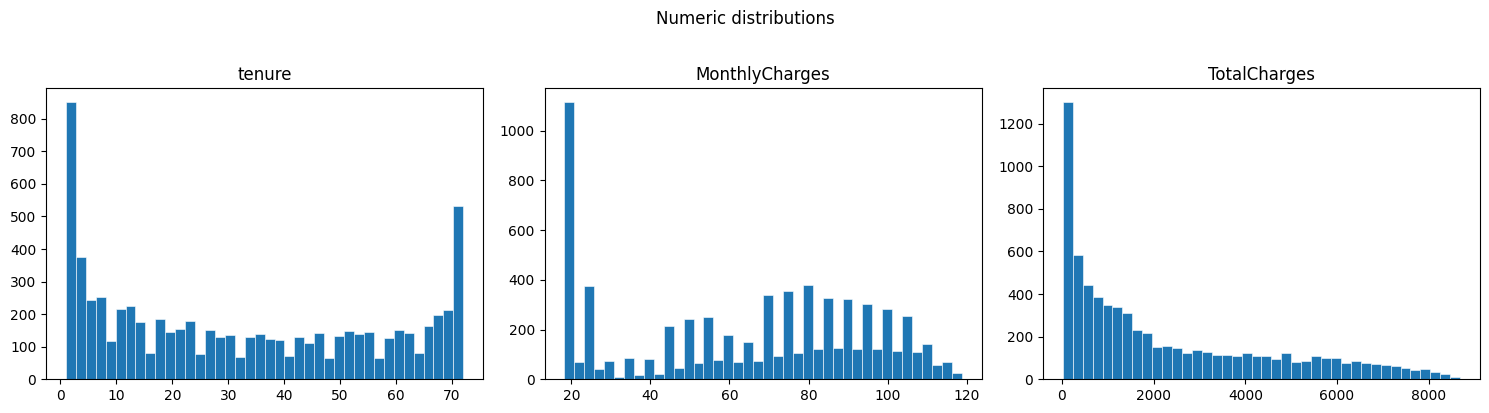

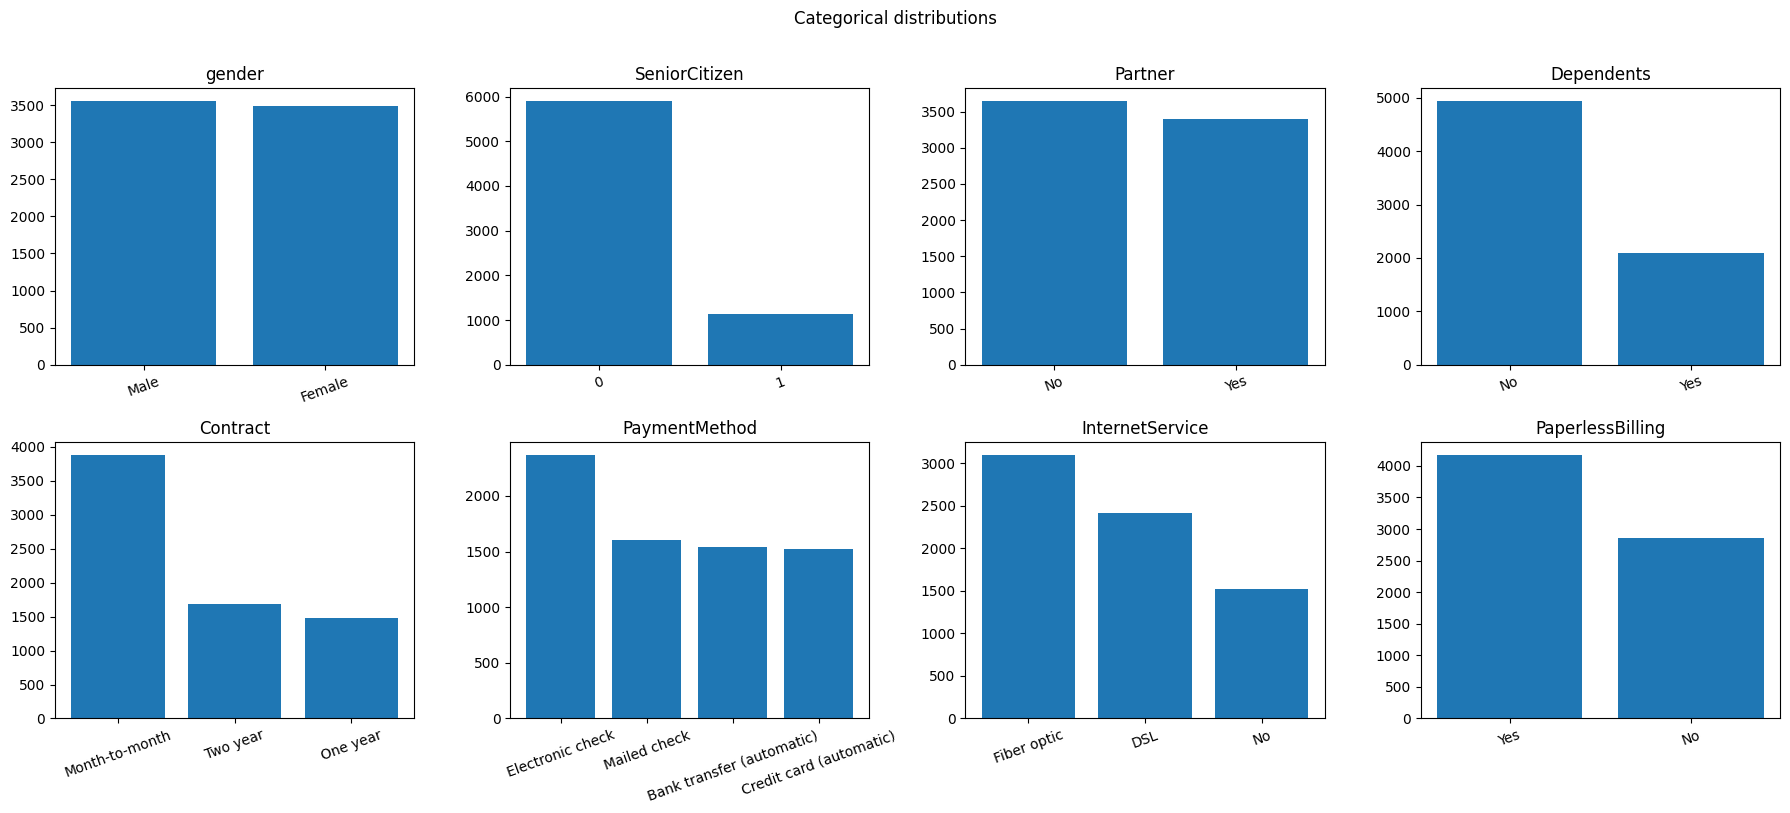

In [12]:
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService',
            'PaperlessBilling']

# Numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=40, edgecolor='white', linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Numeric distributions', y=1.02, fontweight='500')
plt.tight_layout()
plt.show()

# Categorical value counts
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Categorical distributions', y=1.01, fontweight='500')
plt.tight_layout()
plt.show()

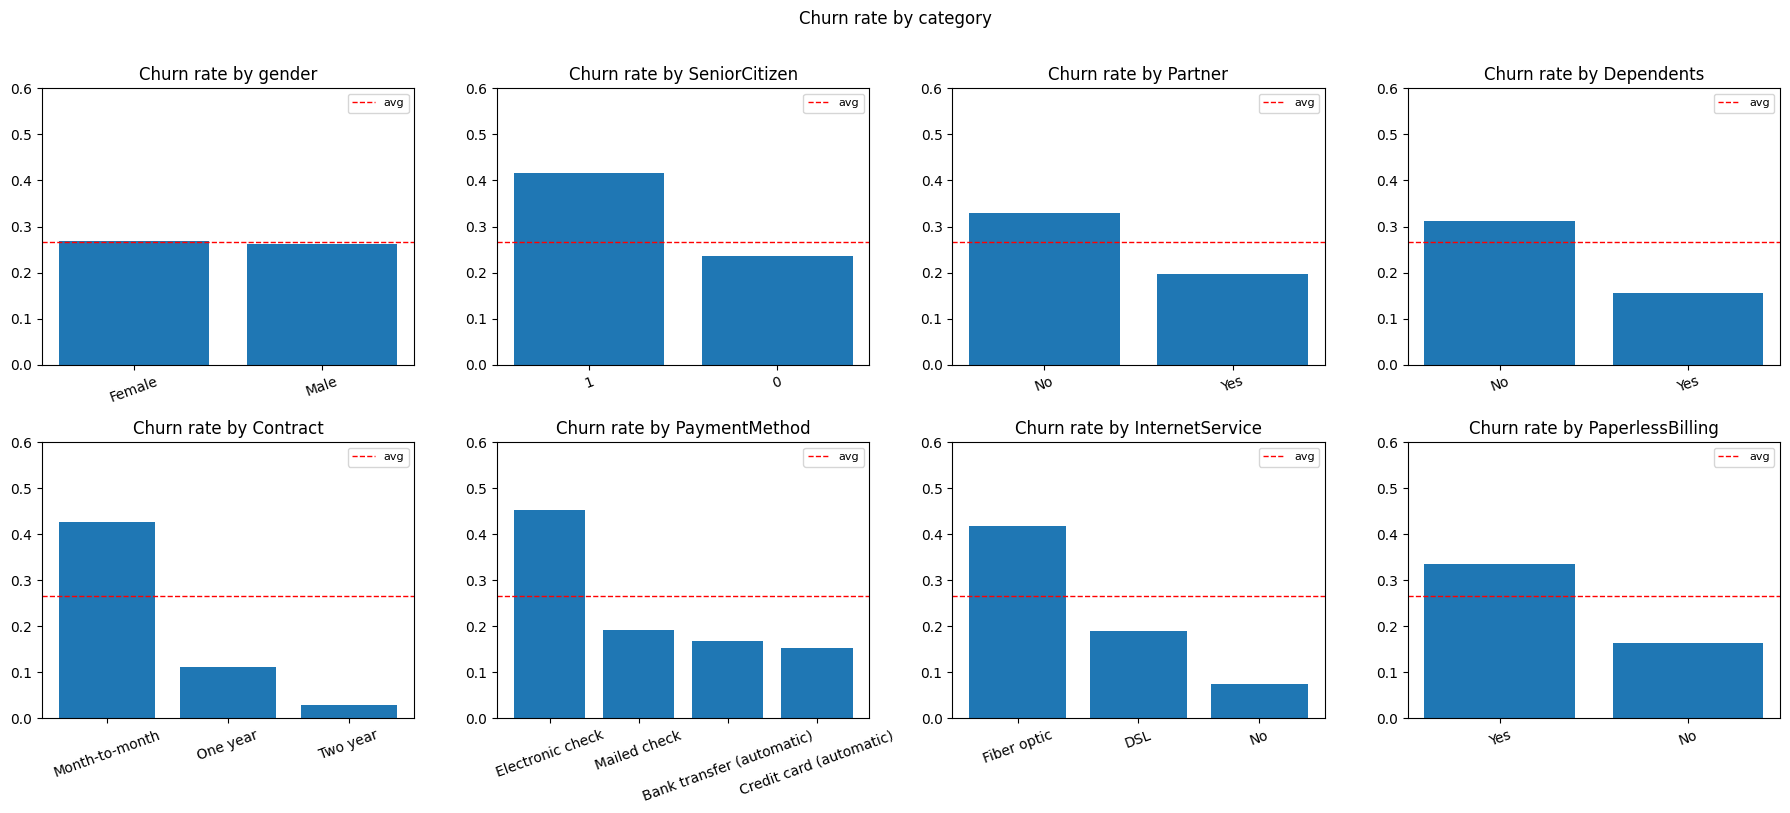

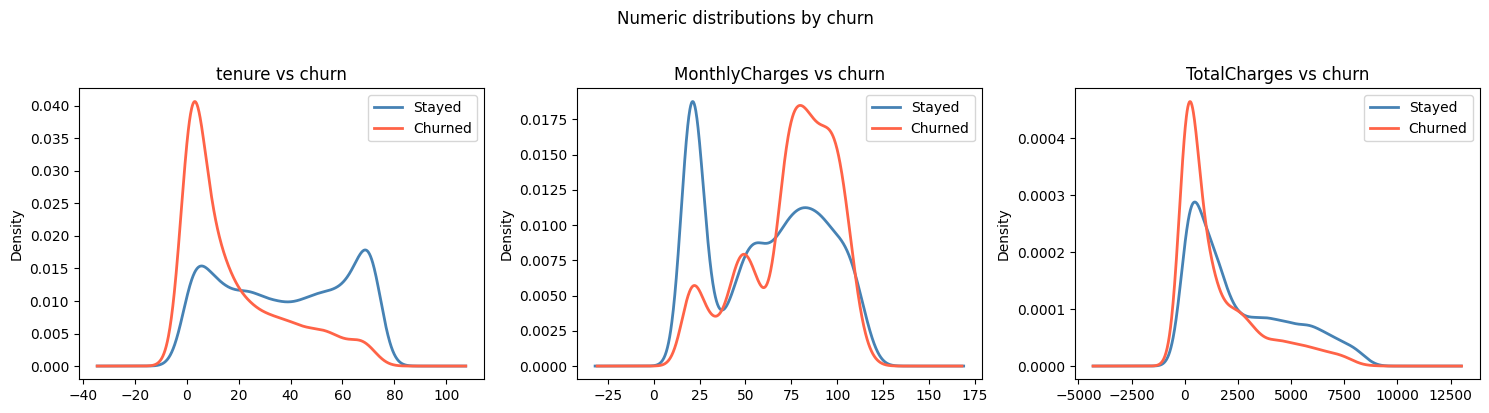


Point-biserial correlation with Churn:
  tenure                r=-0.354  p=9.44e-207
  MonthlyCharges        r=+0.193  p=6.76e-60
  TotalCharges          r=-0.199  p=4.88e-64


In [13]:
# Churn rate by categorical features
from scipy import stats

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values)
    ax.axhline(df['Churn'].mean(), color='red', linestyle='--',
               linewidth=1, label='avg')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylim(0, 0.6)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
plt.suptitle('Churn rate by category', y=1.01, fontweight='500')
plt.tight_layout()
plt.show()

# Numeric vs churn — KDE overlays
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for churn_val, label, color in [(0,'Stayed','steelblue'),
                                     (1,'Churned','tomato')]:
        subset = df[df['Churn'] == churn_val][col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(f'{col} vs churn')
    ax.legend()
plt.suptitle('Numeric distributions by churn', y=1.02, fontweight='500')
plt.tight_layout()
plt.show()

# Correlation of numeric features with churn
print("\nPoint-biserial correlation with Churn:")
for col in num_cols:
    r, p = stats.pointbiserialr(df['Churn'], df[col])
    print(f"  {col:20s}  r={r:+.3f}  p={p:.2e}")

Data prep

In [14]:
fe = df.copy()

In [15]:
# ---- Tenure buckets (EDA will show non-linear churn vs tenure) ----
fe['tenure_group'] = pd.cut(
    fe['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m']
)

In [16]:
# ---- Monthly charge tier ----
fe['charge_tier'] = pd.cut(
    fe['MonthlyCharges'],
    bins=[0, 35, 65, 95, 120],
    labels=['low', 'mid', 'high', 'premium']
)

In [17]:
# ---- Charge per month of tenure (efficiency ratio) ----
fe['avg_monthly_spend'] = fe['TotalCharges'] / (fe['tenure'] + 1)

In [18]:
# ---- Service count (how embedded is this customer?) ----
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
fe['service_count'] = (fe[service_cols] == 'Yes').sum(axis=1)

In [19]:
# ---- Has any internet add-on (security/backup/support) ----
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
fe['has_addon'] = ((fe[addon_cols] == 'Yes').sum(axis=1) > 0).astype(int)

In [20]:
# ---- Month-to-month flag (highest churn risk contract) ----
fe['is_monthly'] = (fe['Contract'] == 'Month-to-month').astype(int)

In [21]:
# ---- Auto payment flag (proxy for engagement/trust) ----
auto_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']
fe['is_autopay'] = fe['PaymentMethod'].isin(auto_methods).astype(int)

In [22]:
# ---- Senior + no support (vulnerable segment) ----
fe['senior_no_support'] = (
    (fe['SeniorCitizen'] == 1) &
    (fe['TechSupport'] == 'No')
).astype(int)

In [23]:
new_feats = ['tenure_group','charge_tier','avg_monthly_spend',
             'service_count','has_addon','is_monthly',
             'is_autopay','senior_no_support']
print(fe[new_feats].describe(include='all').T[['count','unique','mean','std']].fillna('-'))

                    count unique       mean        std
tenure_group       7032.0      4          -          -
charge_tier        7032.0      4          -          -
avg_monthly_spend  7032.0      -  59.083067  30.514438
service_count      7032.0      -   3.363339   2.062067
has_addon          7032.0      -   0.603669   0.489169
is_monthly         7032.0      -   0.551052   0.497422
is_autopay         7032.0      -    0.43558   0.495868
senior_no_support  7032.0      -   0.118032   0.322669


/tmp/ipykernel_58/663171210.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(fe[new_feats].describe(include='all').T[['count','unique','mean','std']].fillna('-'))


In [24]:
from sklearn.preprocessing import LabelEncoder

final = fe.copy()

# Binary yes/no columns → 0/1
yn_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
for col in yn_cols:
    final[col] = (final[col] == 'Yes').astype(int)

In [25]:
# Multi-class categoricals → encoded
encode_cols = ['gender','MultipleLines','InternetService',
               'OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies',
               'Contract','PaymentMethod',
               'tenure_group','charge_tier']

final = pd.get_dummies(
    final,
    columns=encode_cols,
    drop_first=True
)

In [26]:
final.shape

(7032, 44)

In [27]:
final.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24m,tenure_group_25-48m,tenure_group_49-72m,charge_tier_mid,charge_tier_high,charge_tier_premium
0,7590-VHVEG,0,1,0,1,0,1,29.85,29.85,0,...,False,False,True,False,False,False,False,False,False,False
1,5575-GNVDE,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,True,False,True,False,True,False,False
2,3668-QPYBK,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,True,False,False,False,True,False,False
3,7795-CFOCW,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,False,False,False,True,False,True,False,False
4,9237-HQITU,0,0,0,2,1,1,70.70,151.65,1,...,False,False,True,False,False,False,False,False,True,False


In [28]:
# Drop columns not needed for modeling
drop_cols = ['customerID', 'TotalCharges']
final = final.drop(columns=drop_cols)

In [29]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   Churn                                  7032 non-null   int64  
 8   avg_monthly_spend                      7032 non-null   float64
 9   service_count                          7032 non-null   int64  
 10  has_addon                              7032 non-null   int64  
 11  is_m

In [30]:
# Convert all bool columns to int
final = final.astype({col: int for col in final.select_dtypes('bool').columns})

In [31]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   Churn                                  7032 non-null   int64  
 8   avg_monthly_spend                      7032 non-null   float64
 9   service_count                          7032 non-null   int64  
 10  has_addon                              7032 non-null   int64  
 11  is_m

In [32]:
print(final.dtypes.value_counts())
print(final.shape)
print(final.isnull().sum().sum())  # should be 0

int64      40
float64     2
Name: count, dtype: int64
(7032, 42)
0


In [33]:
final['Churn'].mean()

np.float64(0.26578498293515357)

Feature Engineering


In [34]:
# 1. Correlation of every feature with Churn
corr = final.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

is_monthly                               0.405
tenure                                  -0.354
InternetService_Fiber optic              0.307
Contract_Two year                       -0.302
PaymentMethod_Electronic check           0.301
tenure_group_49-72m                     -0.264
TechSupport_No internet service         -0.228
DeviceProtection_No internet service    -0.228
OnlineSecurity_No internet service      -0.228
StreamingTV_No internet service         -0.228
OnlineBackup_No internet service        -0.228
InternetService_No                      -0.228
StreamingMovies_No internet service     -0.228
is_autopay                              -0.210
senior_no_support                        0.199
MonthlyCharges                           0.193
PaperlessBilling                         0.191
Contract_One year                       -0.178
OnlineSecurity_Yes                      -0.171
TechSupport_Yes                         -0.165
Dependents                              -0.163
charge_tier_h

In [35]:
weak = corr[corr.abs() < 0.05].index.tolist()
print("Dropping:", weak)
final = final.drop(columns=weak)

Dropping: ['MultipleLines_Yes', 'charge_tier_mid', 'tenure_group_13-24m', 'MultipleLines_No phone service', 'PhoneService', 'gender_Male']


In [36]:
final.shape

(7032, 36)

In [37]:
corr = final.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

is_monthly                               0.405
tenure                                  -0.354
InternetService_Fiber optic              0.307
Contract_Two year                       -0.302
PaymentMethod_Electronic check           0.301
tenure_group_49-72m                     -0.264
StreamingTV_No internet service         -0.228
TechSupport_No internet service         -0.228
OnlineSecurity_No internet service      -0.228
OnlineBackup_No internet service        -0.228
InternetService_No                      -0.228
DeviceProtection_No internet service    -0.228
StreamingMovies_No internet service     -0.228
is_autopay                              -0.210
senior_no_support                        0.199
MonthlyCharges                           0.193
PaperlessBilling                         0.191
Contract_One year                       -0.178
OnlineSecurity_Yes                      -0.171
TechSupport_Yes                         -0.165
Dependents                              -0.163
charge_tier_h

In [38]:
#dropping no internet service columns except Internetservice_no because if a user dont have
#internet, rest of the services will only no internet service as value
#removing service_count and addon due to low correlation and _yes values are already there

to_drop = [
    'StreamingTV_No internet service',
    'TechSupport_No internet service',
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'StreamingMovies_No internet service',
    'service_count',
    'has_addon',
]

final = final.drop(columns=[c for c in to_drop if c in final.columns])
final.shape

(7032, 28)

In [39]:
corr = final.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

is_monthly                               0.405
tenure                                  -0.354
InternetService_Fiber optic              0.307
Contract_Two year                       -0.302
PaymentMethod_Electronic check           0.301
tenure_group_49-72m                     -0.264
InternetService_No                      -0.228
is_autopay                              -0.210
senior_no_support                        0.199
MonthlyCharges                           0.193
PaperlessBilling                         0.191
Contract_One year                       -0.178
OnlineSecurity_Yes                      -0.171
TechSupport_Yes                         -0.165
Dependents                              -0.163
charge_tier_high                         0.163
SeniorCitizen                            0.151
Partner                                 -0.150
PaymentMethod_Credit card (automatic)   -0.135
PaymentMethod_Mailed check              -0.091
OnlineBackup_Yes                        -0.082
tenure_group_

In [40]:
corr_matrix = final.drop(columns='Churn').corr()

high_corr = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            high_corr.append((cols[i], cols[j], round(val, 3)))

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_df.sort_values('Correlation', key=abs, ascending=False).reset_index()

,index,Feature 1,Feature 2,Correlation
0,4,MonthlyCharges,avg_monthly_spend,0.957
1,3,tenure,tenure_group_49-72m,0.853
2,0,SeniorCitizen,senior_no_support,0.831
3,5,MonthlyCharges,InternetService_Fiber optic,0.787
4,6,MonthlyCharges,InternetService_No,-0.763
5,10,avg_monthly_spend,InternetService_Fiber optic,0.709
6,11,avg_monthly_spend,InternetService_No,-0.692
7,1,tenure,is_monthly,-0.649
8,14,avg_monthly_spend,StreamingMovies_Yes,0.640
9,15,avg_monthly_spend,charge_tier_premium,0.640


In [41]:
#remove features who have high correlation with other features of dataset

to_drop = [
    'avg_monthly_spend',
    'tenure_group_49-72m',
    'tenure_group_25-48m',
    'senior_no_support',
    'is_monthly',
    'is_autopay',
]

final = final.drop(columns=[c for c in to_drop if c in final.columns])
print(f"Shape: {final.shape}")
print(sorted(final.columns.tolist()))

Shape: (7032, 22)
['Churn', 'Contract_One year', 'Contract_Two year', 'Dependents', 'DeviceProtection_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'MonthlyCharges', 'OnlineBackup_Yes', 'OnlineSecurity_Yes', 'PaperlessBilling', 'Partner', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'SeniorCitizen', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'TechSupport_Yes', 'charge_tier_high', 'charge_tier_premium', 'tenure']


In [42]:
final['Churn'].mean()

np.float64(0.26578498293515357)

Modelling

In [43]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 78.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 14.3 MB/s eta 0:00:00


In [44]:
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

In [45]:
X = final.drop(columns='Churn')
y = final['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves 26% churn rate in both splits
)

print(f"Train: {X_train.shape} | Churn: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  | Churn: {y_test.mean():.2%}")

Train: (5625, 21) | Churn: 26.58%
Test:  (1407, 21)  | Churn: 26.58%


In [46]:
mlflow.set_experiment("retentioniq_churn")

with mlflow.start_run(run_name="xgb_baseline"):

    params = {
        "n_estimators"      : 200,
        "max_depth"         : 4,
        "learning_rate"     : 0.05,
        "subsample"         : 0.8,
        "colsample_bytree"  : 0.8,
        "min_child_weight"  : 5,
        "scale_pos_weight"  : (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric"       : "logloss",
        "early_stopping_rounds": 20,
        "random_state"      : 42,
    }

    model = xgb.XGBClassifier(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

2026/06/06 16:14:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/06 16:14:16 INFO mlflow.store.db.utils: Updating database tables
2026/06/06 16:14:19 INFO mlflow.tracking.fluent: Experiment with name 'retentioniq_churn' does not exist. Creating a new experiment.


In [47]:
# ---- Predictions ----
y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.00, 1.01, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, y_pred_t, beta=2))

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Best threshold : {best_threshold:.2f}")
print(f"Best F2 score  : {best_f2:.4f}")

Best threshold : 0.29
Best F2 score  : 0.7468


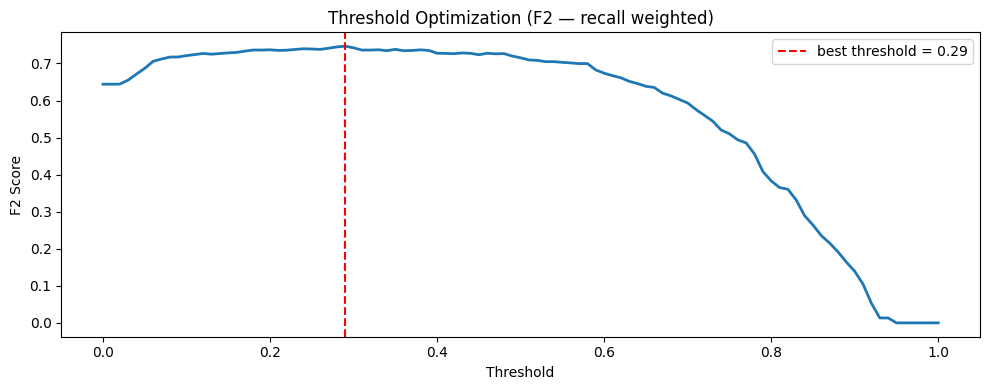

In [49]:
# Plot
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f2_scores, linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.title('Threshold Optimization (F2 — recall weighted)')
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
y_pred = (y_prob >= best_threshold).astype(int)

In [51]:
auc   = roc_auc_score(y_test, y_prob)
f1    = f1_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)

print(f"AUC-ROC   : {auc:.4f}")
print(f"F1        : {f1:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

AUC-ROC   : 0.8404
F1        : 0.5808
Precision : 0.4238
Recall    : 0.9225

              precision    recall  f1-score   support

           0       0.95      0.55      0.69      1033
           1       0.42      0.92      0.58       374

    accuracy                           0.65      1407
   macro avg       0.69      0.73      0.64      1407
weighted avg       0.81      0.65      0.66      1407



In [52]:
 # ---- Log to MLflow ----
mlflow.log_params(params)
mlflow.log_metrics({"auc": auc, "f1": f1,"precision": prec, "recall": rec})
mlflow.xgboost.log_model(model, "model")

2026/06/06 16:14:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


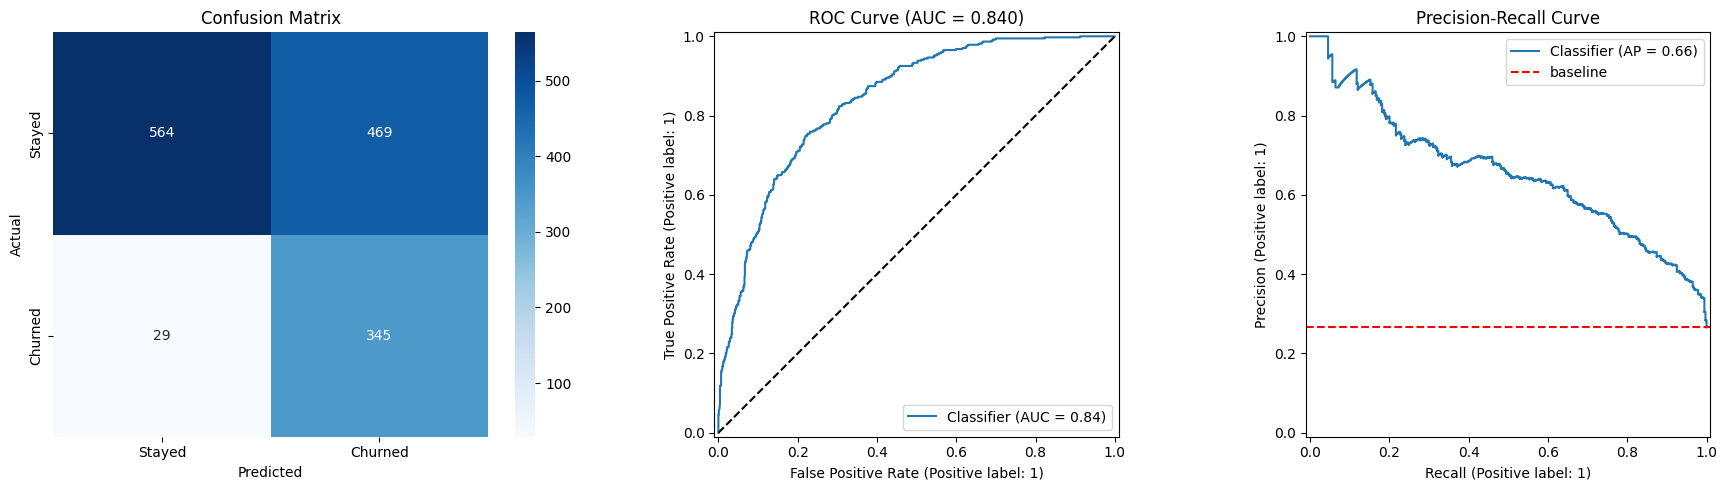

In [53]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Churned'],
            yticklabels=['Stayed','Churned'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'k--')

# PR curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')
axes[2].axhline(y.mean(), color='red', linestyle='--', label='baseline')
axes[2].legend()

plt.tight_layout()
plt.show()

In [54]:
cv_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, eval_metric='logloss'
)

cv_scores = cross_val_score(
    cv_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print(f"CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {cv_scores.round(4)}")

CV AUC: 0.8455 ± 0.0049
Fold scores: [0.8463 0.8541 0.8437 0.8443 0.8393]


# Intervention


In [55]:
np.random.seed(42)

# 50/50 random assignment — no feature bias
df_uplift = final.copy()
df_uplift['treatment'] = np.random.binomial(1, 0.5, size=len(df_uplift))

# Verify balance — churn rate and feature means should be similar across groups
control   = df_uplift[df_uplift['treatment'] == 0]
treatment = df_uplift[df_uplift['treatment'] == 1]

print(f"Control size   : {len(control)}   | Churn rate: {control['Churn'].mean():.3f}")
print(f"Treatment size : {len(treatment)} | Churn rate: {treatment['Churn'].mean():.3f}")

Control size   : 3541   | Churn rate: 0.264
Treatment size : 3491 | Churn rate: 0.268


In [56]:
# Feature mean comparison across groups
balance = pd.DataFrame({
    'control_mean'   : control.drop(columns=['Churn','treatment']).mean(),
    'treatment_mean' : treatment.drop(columns=['Churn','treatment']).mean(),
})
balance['diff'] = (balance['control_mean'] - balance['treatment_mean']).abs()
balance['diff_pct'] = (balance['diff'] / balance['control_mean'].abs() * 100).round(2)

print("\nFeature balance check (diff > 5% would be concerning):")
print(balance.sort_values('diff_pct', ascending=False).round(4).to_string())


Feature balance check (diff > 5% would be concerning):
                                       control_mean  treatment_mean    diff  diff_pct
Contract_Two year                            0.2502          0.2289  0.0213      8.53
PaymentMethod_Credit card (automatic)        0.2254          0.2071  0.0183      8.10
DeviceProtection_Yes                         0.3555          0.3320  0.0236      6.62
PaymentMethod_Mailed check                   0.2211          0.2352  0.0141      6.35
OnlineSecurity_Yes                           0.2945          0.2784  0.0161      5.47
Partner                                      0.4953          0.4695  0.0258      5.22
StreamingTV_Yes                              0.3940          0.3747  0.0193      4.89
charge_tier_premium                          0.1875          0.1808  0.0068      3.61
PaymentMethod_Electronic check               0.3307          0.3420  0.0113      3.42
Contract_One year                            0.2059          0.2128  0.0070      3.3

In [57]:
# Among treatment group who were predicted to churn,
# simulate that 35% of them were saved by the intervention
np.random.seed(42)

df_uplift['outcome'] = df_uplift['Churn'].copy()

# Only churners in treatment group can be saved
churners_treated = (df_uplift['treatment'] == 1) & (df_uplift['Churn'] == 1)
save_prob = np.random.random(churners_treated.sum())

# 35% of treated churners stay due to intervention
df_uplift.loc[churners_treated, 'outcome'] = (save_prob >= 0.35).astype(int)

# Verify
print("Outcome by group:")
print(df_uplift.groupby('treatment')['outcome'].agg(['mean','count']))
print(f"\nChurn rate in control   : {df_uplift[df_uplift['treatment']==0]['outcome'].mean():.3f}")
print(f"Churn rate in treatment : {df_uplift[df_uplift['treatment']==1]['outcome'].mean():.3f}")
# Treatment churn rate should be ~25% lower than control

Outcome by group:
               mean  count
treatment                 
0          0.264050   3541
1          0.170438   3491

Churn rate in control   : 0.264
Churn rate in treatment : 0.170


In [58]:
# Treatment group only — this model learns
# "given these features, probability of churning EVEN AFTER being called"
treat_df = df_uplift[df_uplift['treatment'] == 1].copy()

X_treat = treat_df.drop(columns=['Churn', 'treatment', 'outcome'])
y_treat = treat_df['outcome']  # actual outcome after intervention

X_tr, X_val, y_tr, y_val = train_test_split(
    X_treat, y_treat,
    test_size=0.2,
    stratify=y_treat,
    random_state=42
)

t1_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)

t1_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"T1 model AUC: {roc_auc_score(y_val, t1_model.predict_proba(X_val)[:,1]):.4f}")

T1 model AUC: 0.7640


In [59]:
X_all = df_uplift.drop(columns=['Churn', 'treatment', 'outcome'])

# T0: probability of churning WITHOUT intervention (existing model)
p_churn_no_call   = model.predict_proba(X_all)[:, 1]

# T1: probability of churning even WITH intervention (new model)
p_churn_with_call = t1_model.predict_proba(X_all)[:, 1]

# Uplift = reduction in churn probability due to intervention
# Clip at 0 — calling cannot increase churn probability
uplift = np.clip(p_churn_no_call - p_churn_with_call, 0, None)

df_uplift['p_churn_no_call']   = p_churn_no_call
df_uplift['p_churn_with_call'] = p_churn_with_call
df_uplift['uplift_score']      = uplift

print(f"Uplift score stats:")
print(df_uplift['uplift_score'].describe().round(4))
print(f"\nCustomers with uplift > 0: {(uplift > 0).sum()} ({(uplift > 0).mean():.1%})")

Uplift score stats:
count    7032.0000
mean        0.0452
std         0.0596
min         0.0000
25%         0.0000
50%         0.0169
75%         0.0776
max         0.4227
Name: uplift_score, dtype: float64

Customers with uplift > 0: 4082 (58.0%)


In [63]:
# Call budget = 20% of customer base
call_budget_pct = 0.20
uplift_threshold = df_uplift['uplift_score'].quantile(1 - call_budget_pct)

df_uplift['should_call'] = (df_uplift['uplift_score'] >= uplift_threshold).astype(int)

print(f"Uplift threshold : {uplift_threshold:.4f}")
print(f"Should call = 1  : {df_uplift['should_call'].sum()} customers")
print(f"Should call = 0  : {(df_uplift['should_call']==0).sum()} customers")

print(f"\nActual churn rate:")
print(f"  should_call = 1 : {df_uplift[df_uplift['should_call']==1]['Churn'].mean():.3f}")
print(f"  should_call = 0 : {df_uplift[df_uplift['should_call']==0]['Churn'].mean():.3f}")

print(f"\nAfter call churn rate:")
print(f"  should_call = 1 : {df_uplift[df_uplift['should_call']==1]['outcome'].mean():.3f}")
print(f"  should_call = 0 : {df_uplift[df_uplift['should_call']==0]['outcome'].mean():.3f}")

Uplift threshold : 0.0918
Should call = 1  : 1407 customers
Should call = 0  : 5625 customers

Actual churn rate:
  should_call = 1 : 0.480
  should_call = 0 : 0.212

After call churn rate:
  should_call = 1 : 0.367
  should_call = 0 : 0.180
